In [253]:
import pandas as pd
import numpy as np

In [254]:
data = []

In [255]:
for age in range(10,101):
 if age <=20:
  sport = "Cricket"
 elif age <=40:
  sport = "Football"
 elif age <= 60:
  sport = "Hockey"
 elif age <= 80:
  sport = "vollyball"
 else:
  sport = "Kabbaddi"
 data.append([age,sport])

In [256]:
data.append([age,sport])


In [257]:
df = pd.DataFrame(data, columns=["Age","Sport"])

In [258]:
print(df)

    Age     Sport
0    10   Cricket
1    11   Cricket
2    12   Cricket
3    13   Cricket
4    14   Cricket
..  ...       ...
87   97  Kabbaddi
88   98  Kabbaddi
89   99  Kabbaddi
90  100  Kabbaddi
91  100  Kabbaddi

[92 rows x 2 columns]


In [259]:
df.to_csv("sports_dataset.csv")

step2: Data Augmentation

In [260]:
df = pd.read_csv("sports_dataset.csv")

In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  92 non-null     int64 
 1   Age         92 non-null     int64 
 2   Sport       92 non-null     object
dtypes: int64(2), object(1)
memory usage: 2.3+ KB


In [262]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sport,0


In [263]:
df.describe()

,Unnamed: 0,Age
count,92.00000,92.000000
mean,45.50000,55.489130
std,26.70206,26.683532
min,0.00000,10.000000
25%,22.75000,32.750000
50%,45.50000,55.500000
75%,68.25000,78.250000
max,91.00000,100.000000


In [264]:
df.head()

,Unnamed: 0,Age,Sport
0,0,10,Cricket
1,1,11,Cricket
2,2,12,Cricket
3,3,13,Cricket
4,4,14,Cricket


In [265]:
len(df)


92

In [266]:
df = df.drop_duplicates()

In [267]:
df = df.dropna()

In [268]:
df.head(20)

,Unnamed: 0,Age,Sport
0,0,10,Cricket
1,1,11,Cricket
2,2,12,Cricket
3,3,13,Cricket
4,4,14,Cricket
5,5,15,Cricket
6,6,16,Cricket
7,7,17,Cricket
8,8,18,Cricket
9,9,19,Cricket


In [269]:
df = df[(df["Age"]>=1) & (df["Age"] <= 100)]

In [270]:
df.shape

(92, 3)

In [271]:
df = df.sort_values("Age").reset_index(drop=True)

In [272]:
display(df)

,Unnamed: 0,Age,Sport
0,0,10,Cricket
1,1,11,Cricket
2,2,12,Cricket
3,3,13,Cricket
4,4,14,Cricket
...,...,...,...
87,87,97,Kabbaddi
88,88,98,Kabbaddi
89,89,99,Kabbaddi
90,90,100,Kabbaddi


In [273]:
df.to_csv("sports_dataset_cleaned.csv",index=False)

In [274]:
df = pd.read_csv("sports_dataset_cleaned.csv")

In [275]:
df.shape

(92, 3)

In [276]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [277]:
df = pd.read_csv("sports_dataset_cleaned.csv")

In [278]:
x = df[["Age"]]
y = df[["Sport"]]

In [280]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [281]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [282]:
y_pred = model.predict(x_test)

In [283]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


In [286]:
age = 35
prediction = model.predict([[age]])
print(prediction)

['Football']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [287]:
test_age=[[15],[20],[25],[30]]
prediction=model.predict(test_age)
print(prediction)

['Cricket' 'Cricket' 'Football' 'Football']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [288]:
test_ages = [[15], [20], [25], [30]]
predictions = model.predict(test_ages)
print(predictions)


['Cricket' 'Cricket' 'Football' 'Football']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


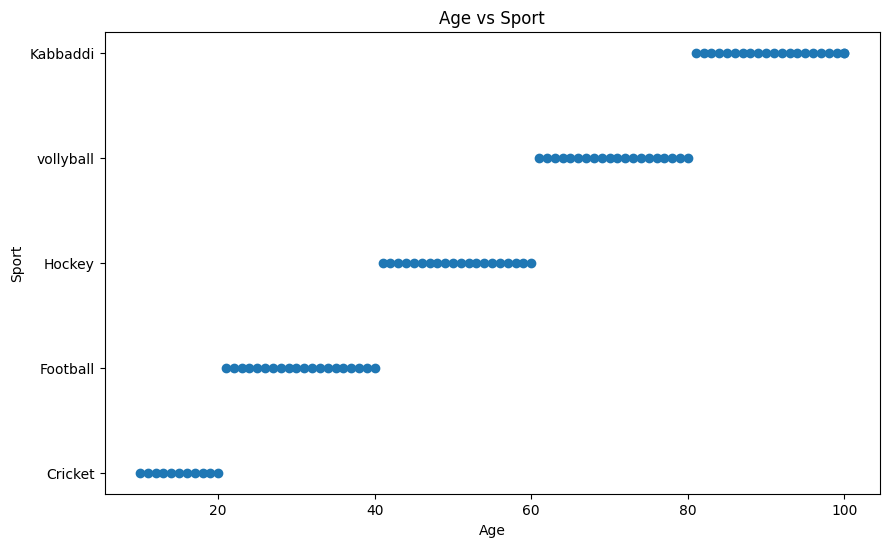

In [289]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df["Age"],df["Sport"])
plt.xlabel("Age")
plt.ylabel("Sport")
plt.title("Age vs Sport")
plt.show()

In [290]:
import pickle

with open("sports_model.pkl","wb") as file:
    pickle.dump(model,file)

    print("Model saved successfully as sports_model.pkl")

Model saved successfully as sports_model.pkl
